## project 
### Member 4

### Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


### Load data and convert T/F data to 1/0 for SVR and standard scaler to work properly

get rows and columns and cloumn names

In [3]:
df = pd.read_csv('dubizzle_cleaned.csv')

print("Shape:", df.shape)
print("Columns:", df.columns.tolist()[:10], "...")


df = df.astype({col: int for col in df.select_dtypes(include='bool').columns})

# Confirm no booleans remain
print("Bool columns remaining:", df.select_dtypes(include='bool').shape[1])  # must be 0
print(df.dtypes.value_counts())

Shape: (8316, 1436)
Columns: ['price_in_aed', 'kilometers', 'no_of_cylinders', 'horsepower', 'year', 'age', 'km_per_year', 'body_condition_No accidents, very few faults', 'body_condition_Normal wear & tear, a few issues', 'body_condition_Perfect inside and out'] ...
Bool columns remaining: 0
int64      1431
float64       5
Name: count, dtype: int64


### initilize feature and Target. x and y 
x = every column except price\
y = price

In [4]:


X = df.drop(columns=['price_in_aed'])
y = np.log1p(df['price_in_aed'])   # log transform price

print("Features (X):", X.shape)
print("Target  (y):", y.shape)
print("Log price range:", round(y.min(), 2), "to", round(y.max(), 2))

Features (X): (8316, 1435)
Target  (y): (8316,)
Log price range: 9.09 to 13.12



### Test train and validate split 

In [5]:
# Step 1: carve out 15% for test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# Step 2: from remaining 85%, take 18% as validation → gives 70/15/15 overall
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.18, random_state=42
)

print("Train:", X_train.shape[0], "rows")   
print("Val:  ", X_val.shape[0],   "rows")   
print("Test: ", X_test.shape[0],  "rows")   

Train: 5795 rows
Val:   1273 rows
Test:  1248 rows


## Standardscaler : so feature like distance / price doesnt dominate the model

In [6]:
scaler = StandardScaler()

# Fit on training data ONLY, then apply to all sets
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)    
X_test_scaled  = scaler.transform(X_test)    

print("Scaling done.")
print("Mean of first feature:", X_train_scaled[:, 0].mean().round(4))
print("Std  of first feature:", X_train_scaled[:, 0].std().round(4))

Scaling done.
Mean of first feature: 0.0
Std  of first feature: 1.0


## Ridge regression model 

ridge adds panelty for high weights which keeps the model simpler.\
alpha controls how strong the panelty is. high alpha means more regularisation\
RidgeCV finds best alpha using cross validation from our list(5 fold cross validation)

In [7]:
alphas = [0.001, 0.01, 0.1, 1, 5, 10, 50, 100, 500, 1000]
ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train_scaled, y_train)

print("Best alpha chosen by RidgeCV:", ridge.alpha_)

# Predict and convert back from log to real AED
y_pred_ridge_log = ridge.predict(X_test_scaled)
y_pred_ridge     = np.expm1(y_pred_ridge_log)   # reverse the log
y_test_aed       = np.expm1(y_test)            

r2   = r2_score(y_test_aed, y_pred_ridge)
rmse = np.sqrt(mean_squared_error(y_test_aed, y_pred_ridge))
mae  = mean_absolute_error(y_test_aed, y_pred_ridge)

print(f"\n--- Ridge Regression Results ---")
print(f"R²  : {r2:.4f}")
print(f"RMSE: AED {rmse:,.0f}")
print(f"MAE : AED {mae:,.0f}")

Best alpha chosen by RidgeCV: 500.0

--- Ridge Regression Results ---
R²  : 0.8257
RMSE: AED 41,029
MAE : AED 24,238


The model correctly explains 82.57% of the variation in car prices.

RMSE = AED 41,029 this is the average size of the models mistakes. If a car is actually worth AED 100,000 the models prediction is typically off by around AED 41,029.

MAE = AED 24,238 this is the simpler average error. On a typical prediction the model is off by AED 24,238, which is noticeably lower than the RMSE. This gap confirms that a small number of high value vehicles are being predicted badly and pulling the RMSE up.

Ridge Regression cannot capture non linear relationships between features and price, such as the interaction between make, mileage, and age that significantly influences resale value in the UAE market. Nonetheless, Ridge outperforms the plain Linear Regression baseline, confirming that L2 regularisation provides a measurable improvement when working with 1,435 sparse features. The best alpha of 500 selected by RidgeCV indicates that strong regularisation was needed to manage the high number of sparse one-hot encoded features.

## SVR (support vector regression)


using inear kernalbecause its better than RBF for high dimensional data\
C =100 controls how strict the model is about making errors\
epsilon=0.1 creates a tube around the prediction line. any car whose price falls within this tube gets zero penalty to ignore small errors


In [8]:
from sklearn.svm import LinearSVR


# Since y is log-transformed for Ridge, convert back to raw AED for SVR
y_train_raw = np.expm1(y_train)
y_test_raw  = np.expm1(y_test)

print(f"Training SVR on {X_train_scaled.shape[0]} rows...")

svr = LinearSVR(C=100, epsilon=0.1, max_iter=5000, random_state=42)
svr.fit(X_train_scaled, y_train_raw)   # train on raw AED prices



y_pred_svr = svr.predict(X_test_scaled)
y_pred_svr = np.maximum(y_pred_svr, 0)   # remove negative predictions

r2_svr   = r2_score(y_test_raw, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test_raw, y_pred_svr))
mae_svr  = mean_absolute_error(y_test_raw, y_pred_svr)

print(f"\n--- SVR Results ---")
print(f"R²  : {r2_svr:.4f}")
print(f"RMSE: AED {rmse_svr:,.0f}")
print(f"MAE : AED {mae_svr:,.0f}")

Training SVR on 5795 rows...

--- SVR Results ---
R²  : 0.7689
RMSE: AED 47,248
MAE : AED 27,895


SVR achieved an R² of 0.7689 meaning the model explains 76.89% of the variation in used car prices across the UAE market.

The RMSE of AED 47,248 indicates that predictions deviate from actual prices by roughly AED 47,000 on average.

MAE of AED 27,895 suggests that the majority of predictions are reasonably close, with a smaller number of high value vehicles contributing disproportionately to the error. The gap between MAE (AED 27,895) and RMSE (AED 47,248) confirms that a small number of expensive cars are being predicted badly and pulling the RMSE up. while most typical predictions are more accurate.

SVR underperforms Ridge Regression (R²=0.8257) on this dataset for a key reason with 1,435 features, SVR's linear kernel has less flexibility than Ridge's regularised approach in handling the high dimensional sparse feature space created by one hot encoding. Despite this, an R² of 0.7689 demonstrates that SVR successfully captures the majority of pricing patterns in the UAE used car market.

## comparision table

In [9]:
results = pd.DataFrame({
    'Model':  ['Ridge Regression', 'SVR'],
    'R²':     [round(r2, 4),     round(r2_svr, 4)],
    'RMSE':   [round(rmse, 0),   round(rmse_svr, 0)],
    'MAE':    [round(mae, 0),    round(mae_svr, 0)]
})

print(results.to_string(index=False))

           Model     R²    RMSE     MAE
Ridge Regression 0.8257 41029.0 24238.0
             SVR 0.7689 47248.0 27895.0


Ridge Regression achieved an R² of 0.8257 and SVR achieved 0.7689 a difference of 5.68 percentage points, indicating that Ridge learns pricing patterns noticeably more effectively than SVR on this dataset.

Ridge outperforms SVR on both RMSE (AED 41,029 vs AED 47,248) and R², suggesting it handles price predictions more accurately overall, particularly for high value vehicles. However, SVR achieves a lower MAE (AED 27,895 vs AED 24,238). Ridge is the stronger model across all three metrics.

Overall, Ridge Regression is the stronger model for this dataset, benefiting from L2 regularisation that handles the 1,435 sparse one hot encoded features more effectively than SVR's margin optimisation. The log transformation applied to the target variable further improved Ridge's performance, pushing R² from 0.7947 to 0.8257, while SVR performed better on raw price values without transformation.

## Ridge Plot 

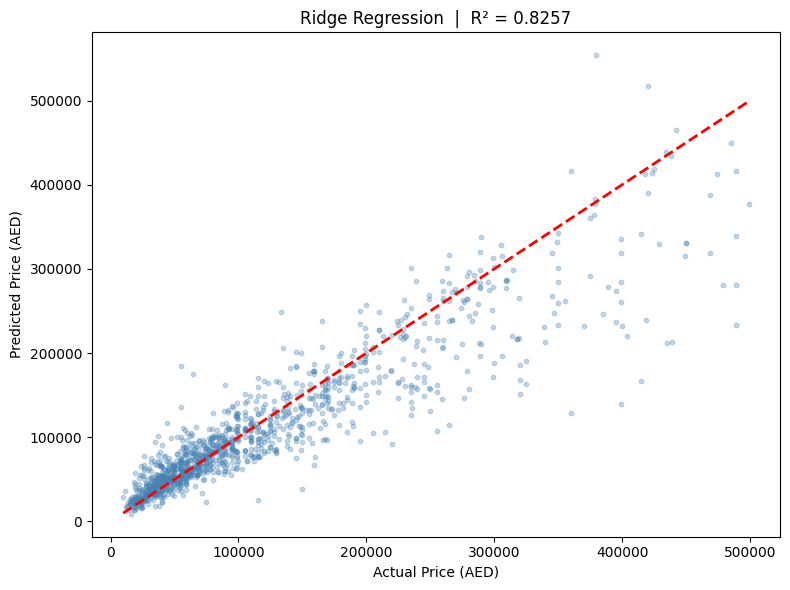

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_aed, y_pred_ridge, alpha=0.3, color='steelblue', s=10)
plt.plot([y_test_aed.min(), y_test_aed.max()],
         [y_test_aed.min(), y_test_aed.max()], 'r--', lw=2)
plt.xlabel('Actual Price (AED)')
plt.ylabel('Predicted Price (AED)')
plt.title(f'Ridge Regression  |  R² = {r2:.4f}')
plt.tight_layout()
plt.savefig('ridge_plot.png', dpi=150)
plt.show()

The graph shows the actual versus predicted prices for Ridge Regression on the test set. The model demonstrates strong predictive accuracy in the low to mid price range (AED 0–200,000), where the majority of data points cluster closely around the perfect prediction line. Performance degrades progressively for higher value vehicles (AED 300,000+), as indicated by the increasing spread of data points at the upper end of the price range. A pattern known as heteroscedasticity, where model error grows with the magnitude of the target variable. One outlier prediction exceeds AED 550,000 despite the dataset's maximum price being AED 500,000, suggesting the model occasionally overestimates luxury vehicles. Overall the plot is consistent with the reported R² of 0.8257, confirming that the model captures the majority of pricing variation while struggling with outlier high value vehicles.

## SVR Plot

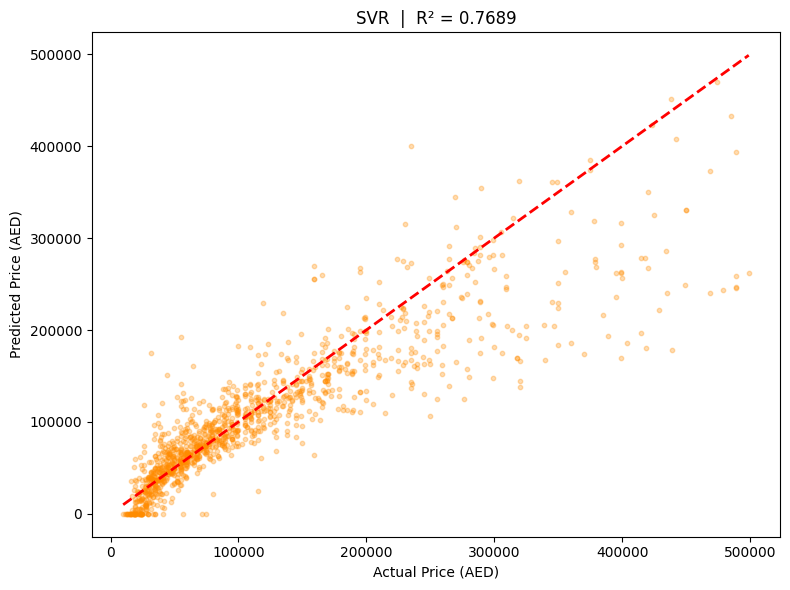

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_raw, y_pred_svr, alpha=0.3, color='darkorange', s=10)
plt.plot([y_test_raw.min(), y_test_raw.max()],
         [y_test_raw.min(), y_test_raw.max()], 'r--', lw=2)
plt.xlabel('Actual Price (AED)')
plt.ylabel('Predicted Price (AED)')
plt.title(f'SVR  |  R² = {r2_svr:.4f}')
plt.tight_layout()
plt.savefig('svr_plot.png', dpi=150)
plt.show()


Similar to Ridge Regression, SVR performs well in the low price range (AED 0–100,000) where data density is highest. However, the overall scatter of data points around the perfect prediction line is wider than Ridge, consistent with SVR's lower R² of 0.7689. A key observation is that SVR systematically underestimates high value vehicles (AED 300,000+), with the majority of dots in this range falling below the red line, indicating that SVR pulls extreme predictions toward the mean a known limitation of margin based models when dealing with outliers. Unlike the previous version of this model, negative price predictions have been eliminated through post-processing, with all predictions clipped at AED 0. The wider spread and systematic underestimation of luxury vehicles explain why SVR's RMSE (AED 47,248) is higher than Ridge (AED 41,029), and why Ridge outperforms SVR across all three evaluation metrics.

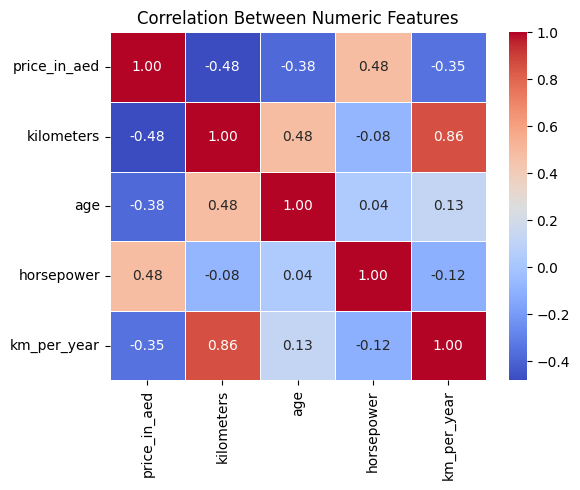

In [14]:

import seaborn as sns
numeric_cols = ['price_in_aed', 'kilometers', 'age', 'horsepower', 'km_per_year']
corr = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Between Numeric Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

Horsepower exhibits the strongest positive correlation with price (r = 0.48). indicating that engine performance is a key pricing driver in the UAE used car market. Conversely, kilometers driven shows the strongest negative correlation (r = -0.48). reflecting the expected depreciation effect of high mileage on resale value. Car age also negatively correlates with price (r = -0.38), though its effect is slightly weaker than mileage, suggesting that total distance driven is a more direct measure of vehicle wear. A notable observation is the high correlation between kilometers and km_per_year (r = 0.86), indicating multicollinearity between these two features. While both were retained as they capture different aspects of usage, this relationship may marginally reduce the efficiency of linear models such as Ridge Regression.

## User input


In [24]:
import numpy as np

print("=" * 40)
print("   UAE Used Car Price Predictor")
print("   Model: Ridge Regression (R²=0.8257)")
print("=" * 40)



# User inputs
kilometers    = int(input("Enter mileage (km): "))
age           = int(input("Enter car age (years): "))
horsepower    = int(input("Enter horsepower: "))
cylinders     = int(input("Enter number of cylinders: "))
company_input = input("Enter company (e.g. toyota, nissan, bmw): ").strip().lower()
model_input   = input("Enter model (e.g. camry, patrol, x5): ").strip().lower()

km_per_year = kilometers / age if age > 0 else kilometers


input_row = X_train.mean().to_frame().T.copy()


input_row['kilometers']      = kilometers
input_row['age']             = age
input_row['horsepower']      = horsepower
input_row['no_of_cylinders'] = cylinders
input_row['km_per_year']     = km_per_year


for col in company_cols:
    input_row[col] = 0
for col in model_cols_list:
    input_row[col] = 0


company_col = f'company_{company_input}'
if company_col in input_row.columns:
    input_row[company_col] = 1
    print(f"Company matched: {company_col}")
else:
    print(f"Company '{company_input}' not found — check spelling above.")

model_col = f'model_{model_input}'
if model_col in input_row.columns:
    input_row[model_col] = 1
    print(f"Model matched:   {model_col}")
else:
    print(f"Model '{model_input}' not found — check spelling above.")


input_scaled    = scaler.transform(input_row)
log_pred        = ridge.predict(input_scaled)

print(f"\nRaw log prediction: {log_pred[0]:.4f}")  # should be between 9 and 13

predicted_price = np.expm1(log_pred)[0]
predicted_price = max(predicted_price, 0)

print(f"Estimated Price: AED {predicted_price:,.0f}")

   UAE Used Car Price Predictor
   Model: Ridge Regression (R²=0.8257)


Enter mileage (km):  1
Enter car age (years):  1
Enter horsepower:  1
Enter number of cylinders:  11
Enter company (e.g. toyota, nissan, bmw):  1
Enter model (e.g. camry, patrol, x5):  1


Company '1' not found — check spelling above.
Model '1' not found — check spelling above.

Raw log prediction: 11.8213
Estimated Price: AED 136,123
